# Dataset Comparison — ViT-S/16

Compares retrieval **accuracy** (mAP, P@K) and **query time** for `vit_s16` across three datasets:

| Dataset | DB size | Query size | Classes |
|---------|---------|------------|---------|
| CIFAR-10 | 50,000 | 10,000 | 10 |
| CIFAR-100 | 50,000 | 10,000 | 100 |
| Texture | 4,335 | 4,335 (self) | 64 |

## 1. Configuration

In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

MODEL = "vit_s16"
K_VALUES = [1, 5, 10]
N_TIMING_QUERIES = 200   # number of sample queries used for timing benchmark

BASE = os.path.dirname(os.path.abspath("compare_datasets.ipynb"))

CONFIGS = {
    "CIFAR-10": {
        "metrics": os.path.join(BASE, "CIFAR10/results/vit_s16_cifar10_metrics.npy"),
        "db_feat": os.path.join(BASE, "CIFAR10/cifar10_features/vit_s16_cifar10_train.pkl"),
        "q_feat":  os.path.join(BASE, "CIFAR10/cifar10_features/vit_s16_cifar10_test.pkl"),
        "color":   "#4C72B0",
    },
    "CIFAR-100": {
        "metrics": os.path.join(BASE, "CIFAR100/results/vit_s16_cifar100_metrics.npy"),
        "db_feat": os.path.join(BASE, "CIFAR100/cifar100_features/vit_s16_cifar100_train.pkl"),
        "q_feat":  os.path.join(BASE, "CIFAR100/cifar100_features/vit_s16_cifar100_test.pkl"),
        "color":   "#DD8452",
    },
    "Texture": {
        "metrics": os.path.join(BASE, "Texture/results/vit_s16_texture_metrics.npy"),
        "db_feat": os.path.join(BASE, "Texture/texture_features/vit_s16_texture.pkl"),
        "q_feat":  None,   # same file used for both DB and query
        "color":   "#55A868",
    },
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Model:  {MODEL}")

Device: cuda
Model:  vit_s16


## 2. Load Saved Metrics

In [2]:
metrics = {}

for name, cfg in CONFIGS.items():
    raw = np.load(cfg["metrics"], allow_pickle=True).item()
    prec = raw["precision@k"]
    metrics[name] = {
        "mAP": float(raw["AP"].mean()),
        **{f"P@{k}": float(prec[k].mean()) for k in K_VALUES if k in prec},
        "n_queries": len(raw["AP"]),
    }
    print(f"{name}: mAP={metrics[name]['mAP']:.4f}  "
          + "  ".join(f"P@{k}={metrics[name][f'P@{k}']:.4f}" for k in K_VALUES if f"P@{k}" in metrics[name]))

CIFAR-10: mAP=0.9836  P@1=0.9790  P@5=0.9787  P@10=0.9787
CIFAR-100: mAP=0.8155  P@1=0.8491  P@5=0.8440  P@10=0.8405
Texture: mAP=0.9980  P@1=0.9998  P@5=0.9995  P@10=0.9993


## 3. Accuracy Comparison

In [3]:
# ── Summary table ─────────────────────────────────────────────────────────────
metric_cols = ["mAP"] + [f"P@{k}" for k in K_VALUES]
table_data  = {name: [metrics[name].get(c, float("nan")) for c in metric_cols]
               for name in CONFIGS}

df_acc = pd.DataFrame(table_data, index=metric_cols).T
print(df_acc.to_string(float_format="{:.4f}".format))

             mAP    P@1    P@5   P@10
CIFAR-10  0.9836 0.9790 0.9787 0.9787
CIFAR-100 0.8155 0.8491 0.8440 0.8405
Texture   0.9980 0.9998 0.9995 0.9993


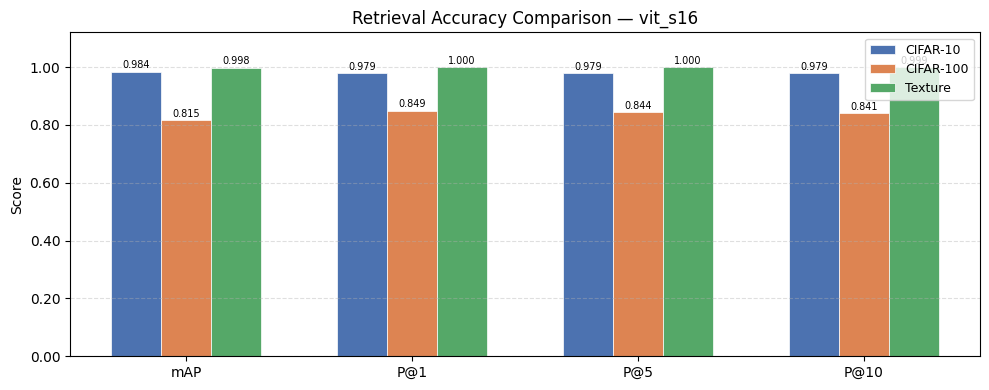

In [4]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
datasets   = list(CONFIGS.keys())
colors     = [CONFIGS[d]["color"] for d in datasets]
n_metrics  = len(metric_cols)
x          = np.arange(n_metrics)
bar_w      = 0.22

fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, color) in enumerate(zip(datasets, colors)):
    vals = [metrics[name].get(c, 0) for c in metric_cols]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=name, color=color, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + bar_w)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title(f"Retrieval Accuracy Comparison — {MODEL}", fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(BASE, f"comparison_accuracy_{MODEL}.png"), dpi=150)
plt.show()

## 4. Query Time Benchmark

Measures the time to retrieve top-10 for a single query: **cosine similarity computation + top-K selection**  
(feature extraction time is the same for all datasets since they share the same model).

In [5]:
timing = {}

for name, cfg in CONFIGS.items():
    print(f"\nLoading features: {name}...")
    db_df = pd.read_pickle(cfg["db_feat"])

    # For Texture, query from the same file; for CIFAR*, load separate test set
    if cfg["q_feat"] is None:
        q_df = db_df
    else:
        q_df = pd.read_pickle(cfg["q_feat"])

    db_matrix = torch.tensor(
        np.array(db_df[MODEL].tolist()), dtype=torch.float32
    ).to(device)
    db_norm = F.normalize(db_matrix, dim=1)  # [N, D]

    # Sample N_TIMING_QUERIES random queries
    sample_idx = np.random.choice(len(q_df), size=min(N_TIMING_QUERIES, len(q_df)), replace=False)
    query_matrix = torch.tensor(
        np.array([q_df.iloc[i][MODEL] for i in sample_idx]), dtype=torch.float32
    ).to(device)
    query_norm = F.normalize(query_matrix, dim=1)  # [Q, D]

    # Warm-up
    _ = (db_norm @ query_norm[:1].T)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # Timed run — one query at a time to get per-query latency
    times = []
    for qi in range(len(sample_idx)):
        q = query_norm[qi].unsqueeze(1)  # [D, 1]
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        scores = (db_norm @ q).squeeze(1)         # [N]
        _      = torch.topk(scores, k=10)         # top-10
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)  # ms

    times = np.array(times)
    timing[name] = {"mean_ms": times.mean(), "std_ms": times.std(), "db_size": len(db_df)}
    print(f"  DB size : {len(db_df):,} images")
    print(f"  Latency : {times.mean():.3f} ± {times.std():.3f} ms  (over {len(sample_idx)} queries)")

    del db_matrix, db_norm, query_matrix, query_norm
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Loading features: CIFAR-10...
  DB size : 50,000 images
  Latency : 0.189 ± 1.311 ms  (over 200 queries)

Loading features: CIFAR-100...
  DB size : 50,000 images
  Latency : 0.086 ± 0.004 ms  (over 200 queries)

Loading features: Texture...
  DB size : 4,335 images
  Latency : 0.044 ± 0.007 ms  (over 200 queries)


In [6]:
# ── Timing table ──────────────────────────────────────────────────────────────
df_time = pd.DataFrame({
    "DB size":     {n: f"{timing[n]['db_size']:,}"        for n in CONFIGS},
    "Mean (ms)":   {n: f"{timing[n]['mean_ms']:.3f}"     for n in CONFIGS},
    "Std (ms)":    {n: f"{timing[n]['std_ms']:.3f}"      for n in CONFIGS},
})
print(df_time.to_string())

          DB size Mean (ms) Std (ms)
CIFAR-10   50,000     0.189    1.311
CIFAR-100  50,000     0.086    0.004
Texture     4,335     0.044    0.007


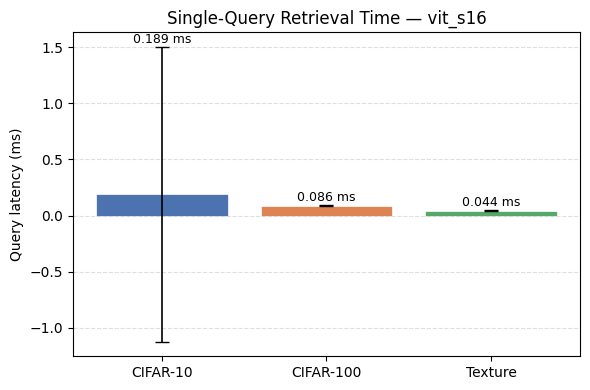

In [7]:
# ── Timing bar chart ──────────────────────────────────────────────────────────
means = [timing[d]["mean_ms"] for d in datasets]
stds  = [timing[d]["std_ms"]  for d in datasets]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(datasets, means, color=colors, edgecolor="white", linewidth=0.5,
              yerr=stds, capsize=5, error_kw={"linewidth": 1.2})
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.01,
            f"{mean:.3f} ms", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Query latency (ms)")
ax.set_title(f"Single-Query Retrieval Time — {MODEL}", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(BASE, f"comparison_timing_{MODEL}.png"), dpi=150)
plt.show()

## 5. Combined Summary

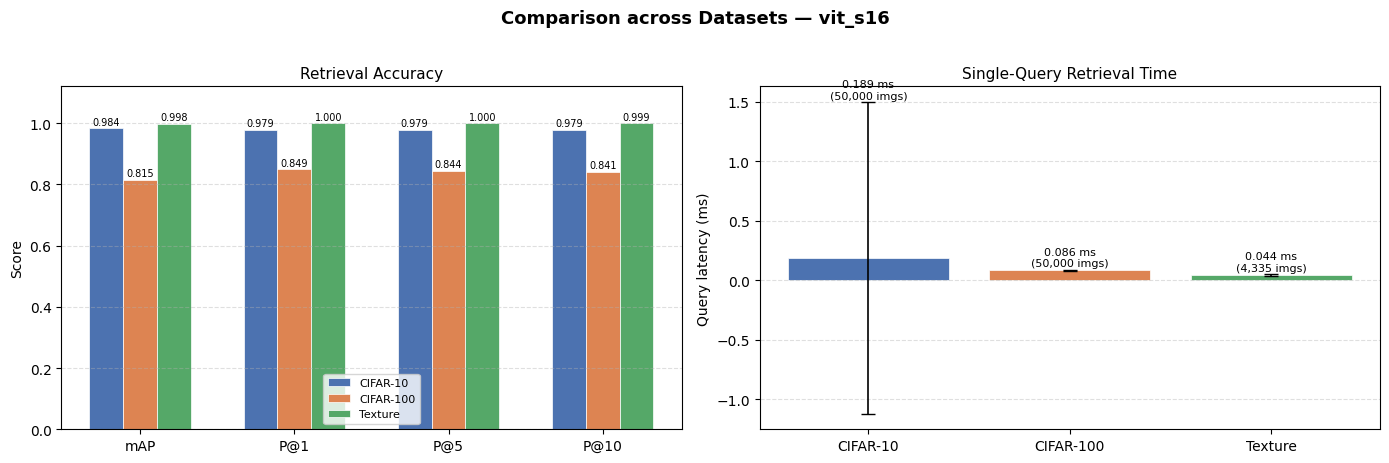

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Left: accuracy ────────────────────────────────────────────────────────────
ax = axes[0]
x  = np.arange(n_metrics)
for i, (name, color) in enumerate(zip(datasets, colors)):
    vals = [metrics[name].get(c, 0) for c in metric_cols]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=name, color=color,
                  edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x + bar_w)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Retrieval Accuracy", fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ── Right: timing ─────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(datasets, means, color=colors, edgecolor="white", linewidth=0.5,
              yerr=stds, capsize=5, error_kw={"linewidth": 1.2})
for bar, mean, std in zip(bars, means, stds):
    db_size = timing[datasets[list(bars).index(bar)]]["db_size"]
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.01,
            f"{mean:.3f} ms\n({db_size:,} imgs)",
            ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Query latency (ms)")
ax.set_title("Single-Query Retrieval Time", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(f"Comparison across Datasets — {MODEL}", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, f"comparison_summary_{MODEL}.png"), dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── Full summary table ────────────────────────────────────────────────────────
summary = {}
for name in CONFIGS:
    summary[name] = {
        "DB size":   timing[name]["db_size"],
        "mAP":       metrics[name]["mAP"],
        **{f"P@{k}": metrics[name].get(f"P@{k}", float("nan")) for k in K_VALUES},
        "Latency (ms)": timing[name]["mean_ms"],
    }

df_summary = pd.DataFrame(summary).T
df_summary["DB size"] = df_summary["DB size"].astype(int)

float_cols = [c for c in df_summary.columns if c != "DB size"]
print(df_summary.to_string(
    formatters={"DB size": "{:,}".format, **{c: "{:.4f}".format for c in float_cols}}
))

          DB size    mAP    P@1    P@5   P@10 Latency (ms)
CIFAR-10   50,000 0.9836 0.9790 0.9787 0.9787       0.1894
CIFAR-100  50,000 0.8155 0.8491 0.8440 0.8405       0.0860
Texture     4,335 0.9980 0.9998 0.9995 0.9993       0.0440
